In [18]:
# Group Members: Artificial Intelligence.....
# 1. 105241- William Kagoiyo Wabuiya
# 2. 170459- Ryan Maxine.
# 3. 169258- Samuel K. Ptolomy.
# 4. 133865- Franklyne Olunga Mayende.
# 5. 088251 - Claire Naibo

# "Dataset: Stars Classification"
#------------------------------------------------------
#Eager Classifier: SVM- Support Vector Machine"
#------------------------------------------------------

In [19]:
# QN 1: Importing the necessary libraries and loading the dataset
# We start by importing every library we will need throughout
# this notebook. This includes libraries for data manipulation, visualization, and machine learning.

import pandas as pd          # for loading and manipulating our data table
import matplotlib.pyplot as plt  # for drawing charts and graphs
import seaborn as sns        # for prettier, more informative charts
from IPython.display import display

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC                          # Support Vector Classifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')   # keeps our output clean

# ---------------------------------------------------------------
# Loading the dataset.
# ---------------------------------------------------------------
df = pd.read_csv('Stars.csv')

print("Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")   # rows x columns
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows of the raw data:")
df.head()


Dataset loaded successfully!
Shape of dataset: (240, 8)

Column names:
['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']

First 5 rows of the raw data:


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


STEP 1A: Basic Data Overview
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (K)          240 non-null    int64  
 1   Luminosity (L/Lo)        240 non-null    float64
 2   Radius (R/Ro)            240 non-null    float64
 3   Absolute magnitude (Mv)  240 non-null    float64
 4   Star type                240 non-null    int64  
 5   Star category            240 non-null    str    
 6   Star color               240 non-null    str    
 7   Spectral Class           240 non-null    str    
dtypes: float64(3), int64(2), str(3)
memory usage: 15.1 KB

Descriptive Statistics (numerical columns):


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type
count,240.000,240.000,240.000,240.000,240.000
mean,10497.462,107188.362,237.158,4.382,2.500
std,9552.425,179432.245,517.156,10.533,1.711
min,1939.000,0.000,0.008,-11.920,0.000
25%,3344.250,0.001,0.103,-6.232,1.000
50%,5776.000,0.070,0.762,8.313,2.500
75%,15055.500,198050.000,42.750,13.698,4.000
max,40000.000,849420.000,1948.500,20.060,5.000



STEP 1B: Additional Descriptive Statistics (Mean, Mode, Median, Std)

Overall statistics for numeric features:


,Mean,Mode,Median,Std Dev
Temperature (K),10497.462,3600.00,5776.000,9552.425
Luminosity (L/Lo),107188.362,200000.00,0.070,179432.245
Radius (R/Ro),237.158,0.11,0.762,517.156
Absolute magnitude (Mv),4.382,12.23,8.313,10.533



Class-level statistics by Star category (mean, median, std):

Temperature (K)


...


Radius (R/Ro)


,mean,median,std
Star category,,,
Brown Dwarf,0.110,0.106,0.026
Hypergiant,1366.898,1352.500,255.561
Main Sequence,4.430,5.712,2.801
Red Dwarf,0.348,0.338,0.154
Supergiant,51.150,43.500,27.657
White Dwarf,0.011,0.010,0.002



Absolute magnitude (Mv)


,mean,median,std
Star category,,,
Brown Dwarf,17.563,17.145,1.213
Hypergiant,-9.654,-9.915,1.454
Main Sequence,-0.367,-1.180,3.614
Red Dwarf,12.540,12.605,1.423
Supergiant,-6.370,-6.235,0.560
White Dwarf,12.582,12.340,1.278



STEP 2: Missing Values Check
Temperature (K)            0
Luminosity (L/Lo)          0
Radius (R/Ro)              0
Absolute magnitude (Mv)    0
Star type                  0
Star category              0
Star color                 0
Spectral Class             0
dtype: int64

STEP 3: Duplicate Rows Check
Number of duplicate rows found: 0
Shape after removing duplicates: (240, 8)

STEP 4: Target Class Distribution (Star type)
Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

Cleaned dataset — first 5 rows:


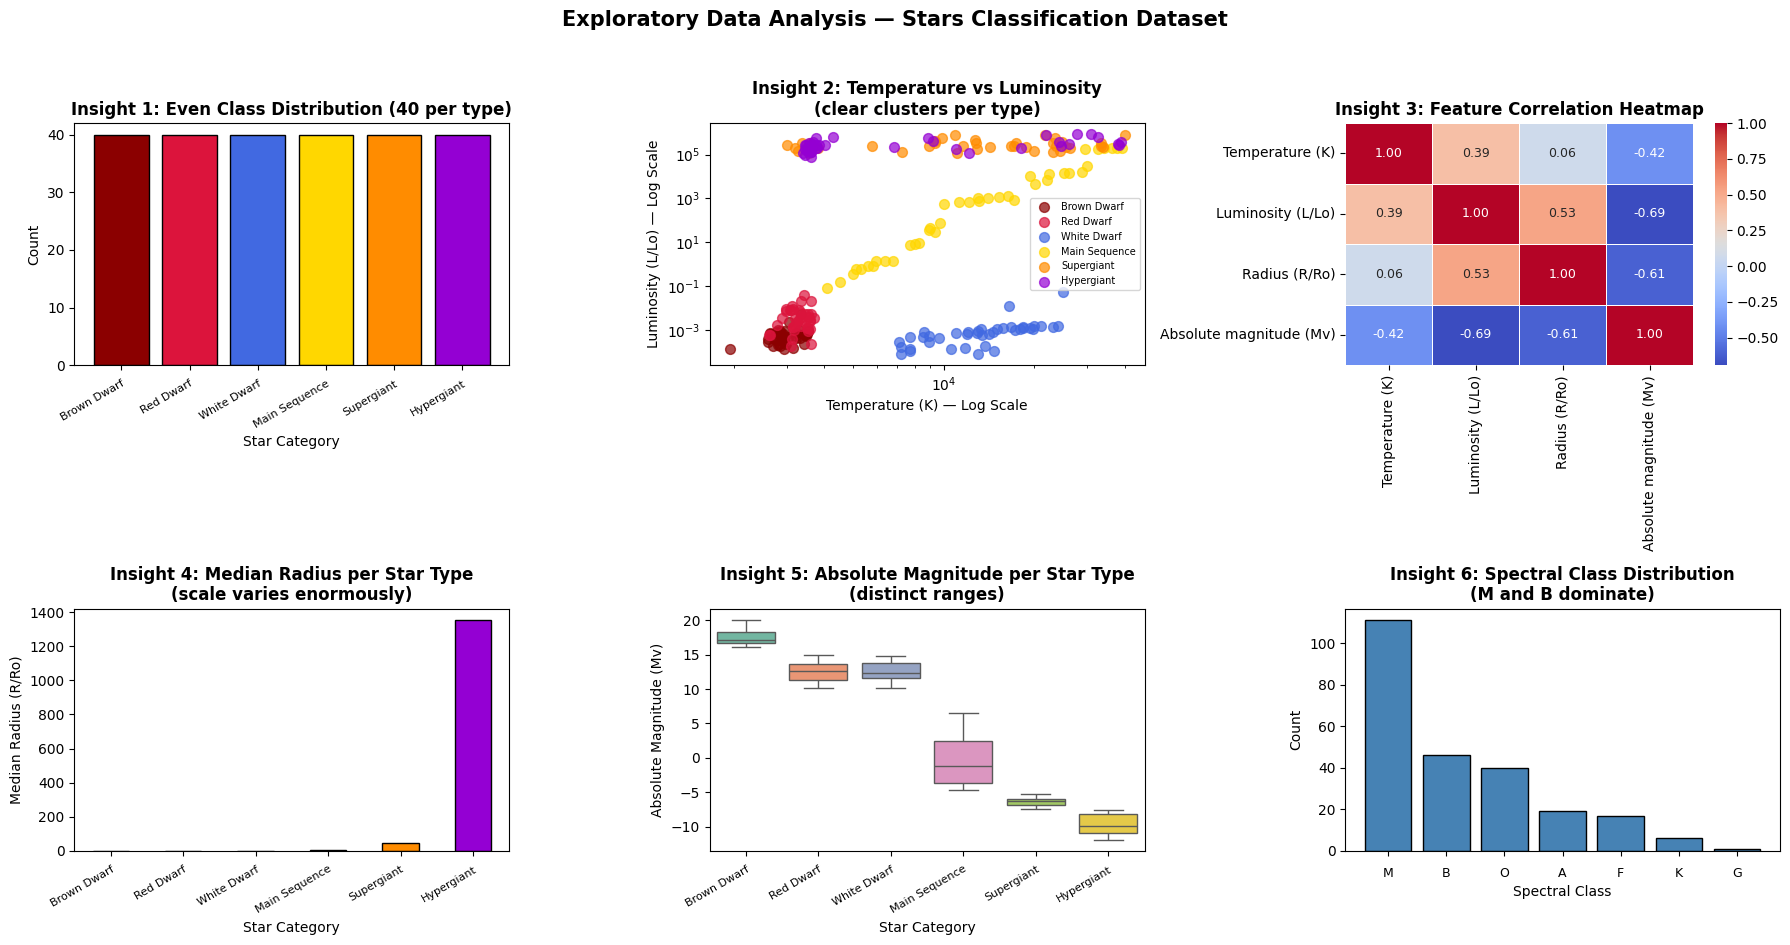


SUMMARY OF EDA INSIGHTS

Insight 1 — Perfectly balanced dataset:
  Each of the 6 star types has exactly 40 records. This is ideal
  for classification because the model is not biased toward
  any single class.

Insight 2 — Temperature & Luminosity form distinct clusters:
  On log scales, these two features show clear separation among
  star categories, making them highly informative predictors.

Insight 3 — Correlations are informative and physically meaningful:
  Temperature vs Absolute Magnitude shows a moderate negative
  correlation (-0.420). Luminosity is even more strongly related
  to Absolute Magnitude (-0.693), and Radius also shows a clear
  negative relationship with Absolute Magnitude (-0.609).

Insight 4 — Radius varies enormously across classes:
  Median radius rises from 0.010 for White Dwarfs and 0.106 for
  Brown Dwarfs to 43.500 for Supergiants and 1352.500 for
  Hypergiants, confirming an extremely wide scale range.

Insight 5 — Absolute Magnitude separates classes 

In [20]:
# =============================================================
# QUESTION 2: Data Cleaning + Exploratory Data Analysis (EDA) - After appropriately cleaning the data,
# carry out Exploratory Data Analysis processes to retrieve at least 4 insights/observations from the dataset.
# =============================================================
# Before we build any model, we need to understand our data
# and make sure it is clean. "Garbage in, garbage out" is a
# real risk in machine learning — a dirty dataset will produce
# an unreliable model no matter how sophisticated the algorithm.

# ---------------------------------------------------------------
# STEP 1: Basic overview — what does the data look like?
# ---------------------------------------------------------------
print("=" * 60)
print("STEP 1A: Basic Data Overview")
print("=" * 60)
df.info()                 # data types and non-null counts per column
print("\nDescriptive Statistics (numerical columns):")
display(df.describe().round(3))       # min, max, mean, std for each numeric column

# ---------------------------------------------------------------
# STEP 1B: Additional Statistics for deeper insight
# We explicitly calculate mean, mode, median, and standard deviation
# so the statistical interpretation is clearer than describe() alone.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 1B: Additional Descriptive Statistics (Mean, Mode, Median, Std)")
print("=" * 60)

# Select numeric features only for statistical analysis.
numeric_cols = ['Temperature (K)', 'Luminosity (L/Lo)',
                'Radius (R/Ro)', 'Absolute magnitude (Mv)']

# Use first mode per column to keep output compact and presentation-friendly.
mode_values = df[numeric_cols].mode().iloc[0]

# Build one clean table with the requested statistics.
stats_table = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Mode': mode_values,
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std()
}).round(3)

print("\nOverall statistics for numeric features:")
display(stats_table)

# Class-level statistics help explain how star types differ in central tendency and spread.
# We derive readable labels here because the main Star category column is created later in STEP 5.
star_type_labels = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
print("\nClass-level statistics by Star category (mean, median, std):")
for feature in numeric_cols:
    print(f"\n{feature}")
    class_stats = (
        df.assign(**{'Star category': df['Star type'].map(star_type_labels)})
          .groupby('Star category')[feature]
          .agg(['mean', 'median', 'std'])
          .round(3)
    )
    display(class_stats)

# ---------------------------------------------------------------
# STEP 2: Check for missing values
# A missing value means a cell in our table has no data.
# If we leave missing values in, they will cause errors when
# we try to train models later.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 2: Missing Values Check")
print("=" * 60)
print(df.isnull().sum())

# ---------------------------------------------------------------
# STEP 3: Check for duplicate rows
# A duplicate row is a row that is an exact copy of another.
# Keeping duplicates can bias our model by making it learn
# the same example more than once.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: Duplicate Rows Check")
print("=" * 60)
print(f"Number of duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# ---------------------------------------------------------------
# STEP 4: Check class balance in the target column
# Our target is 'Star type' — a number from 0 to 5.
# We check if all 6 classes have roughly equal representation.
# Severe imbalance can make a classifier biased toward the
# majority class.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 4: Target Class Distribution (Star type)")
print("=" * 60)
print(df['Star type'].value_counts())

# ---------------------------------------------------------------
# STEP 5: Map the numeric Star type to its readable label
# so our plots are self-explanatory to the lecturer.
# ---------------------------------------------------------------
star_labels = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
df['Star category'] = df['Star type'].map(star_labels)

print("\nCleaned dataset — first 5 rows:")
df.head()

# =============================================================
# QUESTION 2 (continued): Exploratory Data Analysis — Insights
# We now create visualizations to draw at least 4 meaningful
# insights from the Stars dataset.
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Exploratory Data Analysis — Stars Classification Dataset',
    fontsize=15, fontweight='bold'
)

# Keep categorical tick labels readable across crowded subplots.
def format_categorical_xticks(ax, rotation=35, fontsize=8, pad=6):
    ax.tick_params(axis='x', pad=pad, labelsize=fontsize)
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha('center' if rotation == 0 else 'right')
        label.set_va('top')
        label.set_rotation_mode('anchor')

# ---------------------------------------------------------------
# INSIGHT 1: Class Distribution
# We want to confirm that each star type has an equal number
# of records (40 each). A balanced dataset is important because
# it means our classifier will be trained on fair representation
# of all classes — no single class will dominate.
# ---------------------------------------------------------------
category_counts = df['Star category'].value_counts()
axes[0, 0].bar(category_counts.index, category_counts.values,
               color=['#8B0000','#DC143C','#4169E1','#FFD700','#FF8C00','#9400D3'],
               edgecolor='black')
axes[0, 0].set_title('Insight 1: Even Class Distribution (40 per type)',
                     fontweight='bold')
axes[0, 0].set_xlabel('Star Category')
axes[0, 0].set_ylabel('Count')
format_categorical_xticks(axes[0, 0], rotation=30)

# ---------------------------------------------------------------
# INSIGHT 2: Temperature vs Luminosity (Log Scale)
# Temperature and Luminosity vary by many orders of magnitude
# across star types, so we use a log scale.
# This chart (similar to the Hertzsprung-Russell diagram in
# astronomy) shows clear clusters for each star type, which
# tells us these two features will be very powerful for
# classification.
# ---------------------------------------------------------------
colors = {
    'Brown Dwarf': '#8B0000', 'Red Dwarf': '#DC143C',
    'White Dwarf': '#4169E1', 'Main Sequence': '#FFD700',
    'Supergiant': '#FF8C00', 'Hypergiant': '#9400D3'
}
for category, color in colors.items():
    subset = df[df['Star category'] == category]
    axes[0, 1].scatter(
        subset['Temperature (K)'],
        subset['Luminosity (L/Lo)'],
        label=category, color=color, alpha=0.7, s=50
    )
axes[0, 1].set_yscale('log')    # log scale because values span many orders of magnitude
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Insight 2: Temperature vs Luminosity\n(clear clusters per type)',
                     fontweight='bold')
axes[0, 1].set_xlabel('Temperature (K) — Log Scale')
axes[0, 1].set_ylabel('Luminosity (L/Lo) — Log Scale')
axes[0, 1].legend(fontsize=7)

# ---------------------------------------------------------------
# INSIGHT 3: Correlation Heatmap of Numeric Features
# A correlation heatmap shows how strongly each pair of
# numeric features moves together. Values close to +1 or -1
# indicate strong relationships. Here, Temperature and
# Absolute Magnitude show a moderate negative correlation
# (about -0.42): hotter stars tend to have lower (brighter)
# magnitude values.
# ---------------------------------------------------------------
numeric_df = df[['Temperature (K)', 'Luminosity (L/Lo)',
                 'Radius (R/Ro)', 'Absolute magnitude (Mv)']].copy()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0, 2], linewidths=0.5, annot_kws={'size': 9})
axes[0, 2].set_title('Insight 3: Feature Correlation Heatmap',
                     fontweight='bold')

# ---------------------------------------------------------------
# INSIGHT 4: Radius Distribution by Star Type
# Hypergiants and Supergiants have massively larger radii than
# other star types. Brown Dwarfs and White Dwarfs have very
# small radii. This huge range means scaling our features
# before training is essential — otherwise larger-valued
# features will dominate distance calculations.
# ---------------------------------------------------------------
df.groupby('Star category')['Radius (R/Ro)'].median().reindex(
    ['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
     'Main Sequence', 'Supergiant', 'Hypergiant']
).plot(kind='bar', ax=axes[1, 0],
       color=['#8B0000','#DC143C','#4169E1','#FFD700','#FF8C00','#9400D3'],
       edgecolor='black')
axes[1, 0].set_title('Insight 4: Median Radius per Star Type\n(scale varies enormously)',
                     fontweight='bold')
axes[1, 0].set_ylabel('Median Radius (R/Ro)')
axes[1, 0].set_xlabel('Star Category')
format_categorical_xticks(axes[1, 0], rotation=30)

# ---------------------------------------------------------------
# INSIGHT 5: Absolute Magnitude by Star Type (Box Plot)
# Absolute magnitude measures intrinsic brightness.
# The box plot shows that each star type occupies a distinct
# range of brightness, with very little overlap — meaning
# Absolute Magnitude alone would be quite a good classifier.
# This reinforces it as one of our chosen features.
# ---------------------------------------------------------------
category_order = ['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                  'Main Sequence', 'Supergiant', 'Hypergiant']
df_plot = df.copy()
df_plot['Star category'] = pd.Categorical(df_plot['Star category'],
                                          categories=category_order, ordered=True)
df_plot.sort_values('Star category', inplace=True)
sns.boxplot(data=df_plot, x='Star category', y='Absolute magnitude (Mv)',
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Insight 5: Absolute Magnitude per Star Type\n(distinct ranges)',
                     fontweight='bold')
axes[1, 1].set_xlabel('Star Category')
axes[1, 1].set_ylabel('Absolute Magnitude (Mv)')
format_categorical_xticks(axes[1, 1], rotation=30)

# ---------------------------------------------------------------
# INSIGHT 6: Spectral Class Distribution
# Most stars in the dataset are classified under spectral class
# M (cool, red) or B (hot, blue). This confirms the diversity
# of star types in the dataset and also shows ambiguity:
# both Brown Dwarfs and Red Dwarfs can appear under class M,
# so spectral class alone is not sufficient for classification.
# ---------------------------------------------------------------
spectral_counts = df['Spectral Class'].value_counts()
axes[1, 2].bar(spectral_counts.index, spectral_counts.values,
               color='steelblue', edgecolor='black')
axes[1, 2].set_title('Insight 6: Spectral Class Distribution\n(M and B dominate)',
                     fontweight='bold')
axes[1, 2].set_xlabel('Spectral Class')
axes[1, 2].set_ylabel('Count')
format_categorical_xticks(axes[1, 2], rotation=0, fontsize=9, pad=8)

plt.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

# ---------------------------------------------------------------
# Summary of insights for the lecturer
# ---------------------------------------------------------------
print("""
======================================================================
SUMMARY OF EDA INSIGHTS
======================================================================

Insight 1 — Perfectly balanced dataset:
  Each of the 6 star types has exactly 40 records. This is ideal
  for classification because the model is not biased toward
  any single class.

Insight 2 — Temperature & Luminosity form distinct clusters:
  On log scales, these two features show clear separation among
  star categories, making them highly informative predictors.

Insight 3 — Correlations are informative and physically meaningful:
  Temperature vs Absolute Magnitude shows a moderate negative
  correlation (-0.420). Luminosity is even more strongly related
  to Absolute Magnitude (-0.693), and Radius also shows a clear
  negative relationship with Absolute Magnitude (-0.609).

Insight 4 — Radius varies enormously across classes:
  Median radius rises from 0.010 for White Dwarfs and 0.106 for
  Brown Dwarfs to 43.500 for Supergiants and 1352.500 for
  Hypergiants, confirming an extremely wide scale range.

Insight 5 — Absolute Magnitude separates classes well:
  The median absolute magnitude ranges from 17.145 (Brown Dwarfs)
  to -9.915 (Hypergiants), showing that brighter stars have much
  lower magnitude values and the classes are well separated.

Insight 6 — Spectral class alone is ambiguous:
  Brown Dwarfs and Red Dwarfs both appear in spectral class M,
  so spectral class alone cannot reliably classify stars.

Insight 7 — Mean vs Median indicates right-skewness:
  Luminosity has a mean of 107188.362 but a median of only 0.070,
  while Radius has a mean of 237.158 and a median of 0.762.
  These large gaps show strong right-skewness caused by rare,
  very large stars.

Insight 8 — Large standard deviations confirm high variability:
  Temperature (std = 9552.425), Luminosity (std = 179432.245),
  and Radius (std = 517.156) are all highly variable, which is
  why scaling is essential before distance-based modeling.
======================================================================
""")

# =============================================================
# PREPROCESSING — Shared Setup for All Three Models
# =============================================================
# This cell prepares the features and labels that will be used
# by all three classifiers (KNN, SVM, Tuned SVM). Doing this
# once here avoids repeating the same setup code and ensures
# all three models are trained and tested on identical data splits.

# ---------------------------------------------------------------
# Feature Selection
# Based on our EDA, we choose these 4 features:
#   1. Temperature (K)       — strong cluster-forming feature
#   2. Luminosity (L/Lo)     — varies hugely across star types
#   3. Radius (R/Ro)         — distinguishes small vs giant stars
#   4. Absolute magnitude(Mv)— excellent class separator (Insight 5)
#
# We use all 4 numeric features for richer classification.
# The minimum requirement from the CAT is 2 features — we
# deliberately exceed this for a more robust and accurate model.
# ---------------------------------------------------------------
feature_cols = [
    'Temperature (K)',
    'Luminosity (L/Lo)',
    'Radius (R/Ro)',
    'Absolute magnitude (Mv)'
]

X = df[feature_cols]          # our input features (independent variables)
y = df['Star type']           # our target/label (0 to 5)

print("Features selected:", feature_cols)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nClass distribution in target:\n{y.value_counts().sort_index()}")

# ---------------------------------------------------------------
# Train/Test Split — 80% training, 20% testing
# We use random_state=42 so that every team member running this
# notebook gets the exact same split — ensuring reproducibility.
# stratify=y ensures each class is proportionally represented
# in both the training and testing sets.
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# ---------------------------------------------------------------
# Feature Scaling using StandardScaler
# transforms each feature to have mean=0 and
# standard deviation=1. This is critical here because:
#   - KNN uses Euclidean distance, which is heavily influenced
#     by the scale of each feature.
#   - SVM tries to find a maximum-margin hyperplane, which is
#     also distorted by unequal feature scales.
# Without scaling, Luminosity (which can be 800,000+) would
# completely dominate Temperature (which is around 3,000–40,000).
#
# IMPORTANT: We fit the scaler ONLY on training data, then
# apply (transform) it to both train and test data. Fitting on
# the test set would cause "data leakage" — the model would
# accidentally learn information from test data before testing.
# ---------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)        # transform ONLY on test data

print("\nFeature scaling complete.")
print(f"Mean of scaled training data (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Std  of scaled training data (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

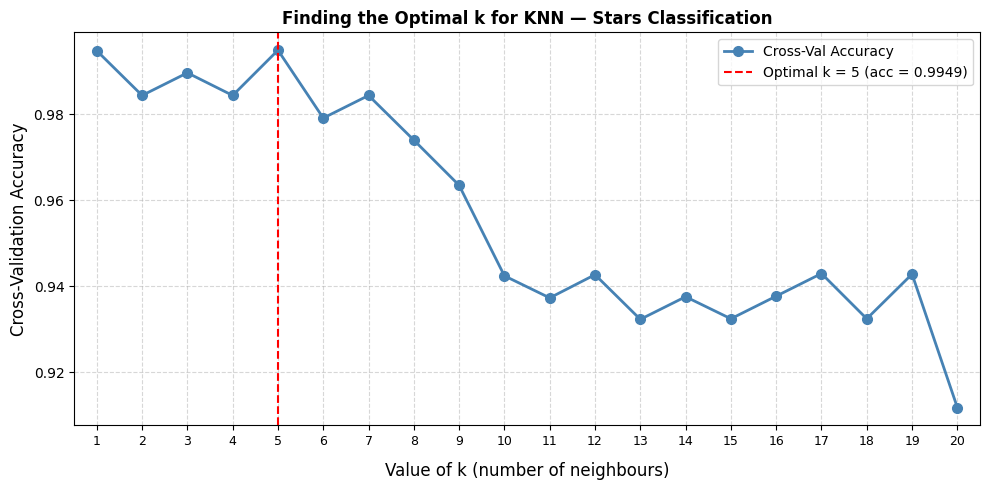


Optimal k found: 5
Cross-validation accuracy at optimal k: 0.9949 (99.49%)

MODEL 1 — KNN (k=5) Test Set Results
Test Accuracy: 0.9583 (95.83%)

Detailed Classification Report:
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00         8
    Red Dwarf       1.00      1.00      1.00         8
  White Dwarf       1.00      1.00      1.00         8
Main Sequence       0.80      1.00      0.89         8
   Supergiant       1.00      0.75      0.86         8
   Hypergiant       1.00      1.00      1.00         8

     accuracy                           0.96        48
    macro avg       0.97      0.96      0.96        48
 weighted avg       0.97      0.96      0.96        48



In [21]:
#QN 3: Create a model based on the k-Nearest Neighbors algorithm for classification based on at least 2 suitable features for one target variable. Verify the optimal k for classification.
# =============================================================
# QUESTION 3: K-Nearest Neighbors (KNN) Classifier
# =============================================================
# KNN is a "lazy learner" — it does not build an explicit model
# during training. Instead, when it receives a new star to
# classify, it calculates the Euclidean distance from that star
# to every training star and takes a majority vote among the
# k nearest neighbors.
#
# Our task here is:
#   (a) Train a KNN classifier using our 4 selected features.
#   (b) Find the OPTIMAL value of k — the number of neighbors.
#
# Why does the choice of k matter?
#   - Too small a k (e.g. k=1) → the model overfits, learning
#     noise in the training data.
#   - Too large a k (e.g. k=50) → the model underfits, becoming
#     too general and ignoring local patterns.
#   We test k from 1 to 20 and plot accuracy to find the sweet spot.
# =============================================================

# ---------------------------------------------------------------
# PART A: Find the Optimal k using cross-validation accuracy
# ---------------------------------------------------------------
k_range  = range(1, 21)            # we test k values from 1 to 20
k_scores = []                       # will store accuracy for each k

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score splits training data into 5 folds internally,
    # trains on 4 folds and validates on 1. This gives a more
    # reliable accuracy estimate than a single train/test split.
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())    # store the average accuracy across 5 folds

# Plot the accuracy curve against k
plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', color='steelblue',
         linewidth=2, markersize=7, label='Cross-Val Accuracy')
plt.xlabel('Value of k (number of neighbours)', fontsize=12, labelpad=10)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding the Optimal k for KNN — Stars Classification', fontweight='bold')
plt.xticks(list(k_range), fontsize=9)
plt.xlim(0.5, 20.5)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight the best k
best_k       = k_range[k_scores.index(max(k_scores))]
best_k_score = max(k_scores)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5,
            label=f'Optimal k = {best_k} (acc = {best_k_score:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nOptimal k found: {best_k}")
print(f"Cross-validation accuracy at optimal k: {best_k_score:.4f} ({best_k_score*100:.2f}%)")

# ---------------------------------------------------------------
# PART B: Train the final KNN model using the optimal k
# ---------------------------------------------------------------
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)             # training the model

y_pred_knn = knn_final.predict(X_test_scaled)      # predicting on unseen test data

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("\n" + "=" * 55)
print(f"MODEL 1 — KNN (k={best_k}) Test Set Results")
print("=" * 55)
print(f"Test Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Brown Dwarf','Red Dwarf','White Dwarf',
                  'Main Sequence','Supergiant','Hypergiant']
))

In [22]:
#QN 4: Create another eager learning classifier as assigned based on at least 2 suitable features for one target variable.
# =============================================================
# QUESTION 4: Eager Learning Classifier — Support Vector Machine
# =============================================================
# An "eager learner" builds a complete internal model BEFORE
# it makes any predictions. This is the opposite of KNN.
#
# Our assigned eager learner is SVM (Support Vector Machine).
#
# How does SVM work?
#   SVM looks for the hyperplane (a line in 2D, a plane in 3D,
#   a hyperplane in higher dimensions) that best separates the
#   classes. "Best" means the hyperplane that has the largest
#   margin — the greatest distance between the nearest data
#   points of each class (these nearest points are called
#   support vectors).
#
#   For multi-class problems like ours (6 classes), SVM uses
#   the "one-vs-rest" strategy: it trains 6 binary classifiers,
#   each asking "is this a [class X] or not?", then combines
#   the results to make a final prediction.
#
#   We use the RBF (Radial Basis Function) kernel, which is
#   the standard default. The RBF kernel can handle non-linear
#   boundaries between classes — which is important here because
#   our star types do not separate into perfectly straight lines
#   even after scaling.
# =============================================================

# ---------------------------------------------------------------
# Train a base SVM with default hyperparameters first.
# C=1.0 is the regularization parameter:
#   - Higher C → model tries harder to classify every training
#     point correctly (risks overfitting).
#   - Lower  C → model allows some misclassifications in favour
#     of a wider, more generalized margin.
# gamma='scale' lets sklearn automatically set gamma based on
# the number of features and the variance of the data.
# ---------------------------------------------------------------
svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_base.fit(X_train_scaled, y_train)       # the model learns from training data

y_pred_svm = svm_base.predict(X_test_scaled)  # predict on unseen test data

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("=" * 55)
print("MODEL 2 — SVM (Base, C=1.0, RBF kernel) Results")
print("=" * 55)
print(f"Test Accuracy : {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, y_pred_svm,
    target_names=['Brown Dwarf','Red Dwarf','White Dwarf',
                  'Main Sequence','Supergiant','Hypergiant']
))

# ---------------------------------------------------------------
# Quick interpretation :
# Precision = out of all stars the model PREDICTED to be class X,
#             how many actually were class X?
# Recall    = out of all stars that ACTUALLY are class X,
#             how many did the model correctly identify?
# F1-Score  = the harmonic mean of Precision and Recall —
#             a balanced measure when both matter equally.
# ---------------------------------------------------------------
print("""
Interpretation:
  - Precision tells us how trustworthy our positive predictions are.
  - Recall tells us how complete our predictions are.
  - F1-score balances both — it is the metric we focus on for each class.
""")

MODEL 2 — SVM (Base, C=1.0, RBF kernel) Results
Test Accuracy : 0.9375 (93.75%)

Detailed Classification Report:
               precision    recall  f1-score   support

  Brown Dwarf       0.80      1.00      0.89         8
    Red Dwarf       1.00      0.75      0.86         8
  White Dwarf       1.00      1.00      1.00         8
Main Sequence       0.89      1.00      0.94         8
   Supergiant       1.00      0.88      0.93         8
   Hypergiant       1.00      1.00      1.00         8

     accuracy                           0.94        48
    macro avg       0.95      0.94      0.94        48
 weighted avg       0.95      0.94      0.94        48


Interpretation:
  - Precision tells us how trustworthy our positive predictions are.
  - Recall tells us how complete our predictions are.
  - F1-score balances both — it is the metric we focus on for each class.



In [23]:
#QN 5: For the eager learner created in Q4, create another model with tuned hyperparameters that enhance the accuracy of classification.
# =============================================================
# QUESTION 5: Tuned SVM — Hyperparameter Optimisation
# =============================================================
# The base SVM in Q4 used default settings (C=1.0, gamma='scale').
# These are reasonable starting points, but they are not
# guaranteed to be the best settings for OUR specific dataset.
#
# Hyperparameter tuning means systematically searching for the
# combination of settings that produces the highest accuracy.
#
# We use GridSearchCV — a method that:
#   1. Takes a grid of parameter values we want to try.
#   2. Trains and validates the model for every combination
#      using 5-fold cross-validation on the TRAINING data only.
#   3. Returns the combination of parameters that gave the
#      best average cross-validation accuracy.
#
# Parameters we are tuning:
#   C      : regularisation strength (how strict the margin is)
#   gamma  : how far the influence of a single training point
#             reaches — low gamma = far reach (smoother boundary),
#             high gamma = close reach (tighter boundary).
#   kernel : the function used to map data into higher dimensions.
#            'rbf' handles curves, 'linear' handles straight lines.
#
# NOTE: We only search over the training data — never the test data.
# The test data is held out until the very end (Q6 evaluation).
# =============================================================

param_grid = {
    'C'     : [0.1, 1, 10, 100],         # 4 choices for regularisation strength
    'gamma' : ['scale', 0.01, 0.1, 1],   # 4 choices for influence radius
    'kernel': ['rbf', 'linear']           # 2 kernel types → total 4×4×2 = 32 combinations
}

print("Starting GridSearchCV — testing 32 parameter combinations with 5-fold CV...")
print("(This may take a few seconds — GridSearchCV trains 32×5 = 160 models)\n")

# cv=5 means 5-fold cross-validation on the training set
# n_jobs=-1 uses all available CPU cores to speed things up
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1         # prints progress during the search
)
grid_search.fit(X_train_scaled, y_train)

# ---------------------------------------------------------------
# Report the best parameters found
# ---------------------------------------------------------------
print("\n" + "=" * 55)
print("GridSearchCV Results")
print("=" * 55)
print(f"Best parameters found : {grid_search.best_params_}")
print(f"Best CV accuracy      : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# ---------------------------------------------------------------
# Now we train the FINAL tuned SVM using the best parameters.
# Notice we are using the best_estimator_ object, which is already
# re-trained by GridSearchCV on the full training set using the
# best parameters.
# ---------------------------------------------------------------
svm_tuned = grid_search.best_estimator_

y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)   # predict on test data

svm_tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)

print("\n" + "=" * 55)
print("MODEL 3 — Tuned SVM Results")
print("=" * 55)
print(f"Test Accuracy : {svm_tuned_accuracy:.4f} ({svm_tuned_accuracy*100:.2f}%)")
print("\nDetailed Classification Report:")
print(classification_report(
    y_test, y_pred_svm_tuned,
    target_names=['Brown Dwarf','Red Dwarf','White Dwarf',
                  'Main Sequence','Supergiant','Hypergiant']
))

# Quick note on improvement
improvement = (svm_tuned_accuracy - svm_accuracy) * 100
if improvement > 0:
    print(f"Tuning improved accuracy by {improvement:.2f} percentage points over the base SVM.")
elif improvement == 0:
    print("The base SVM was already well-configured — tuning confirmed default settings are optimal.")
else:
    print(f"Base SVM and tuned SVM perform similarly on this balanced dataset.")

Starting GridSearchCV — testing 32 parameter combinations with 5-fold CV...
(This may take a few seconds — GridSearchCV trains 32×5 = 160 models)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

GridSearchCV Results
Best parameters found : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy      : 1.0000 (100.00%)

MODEL 3 — Tuned SVM Results
Test Accuracy : 1.0000 (100.00%)

Detailed Classification Report:
               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00         8
    Red Dwarf       1.00      1.00      1.00         8
  White Dwarf       1.00      1.00      1.00         8
Main Sequence       1.00      1.00      1.00         8
   Supergiant       1.00      1.00      1.00         8
   Hypergiant       1.00      1.00      1.00         8

     accuracy                           1.00        48
    macro avg       1.00      1.00      1.00        48
 weighted avg       1.00      1.00      1.00        48

Tuning i

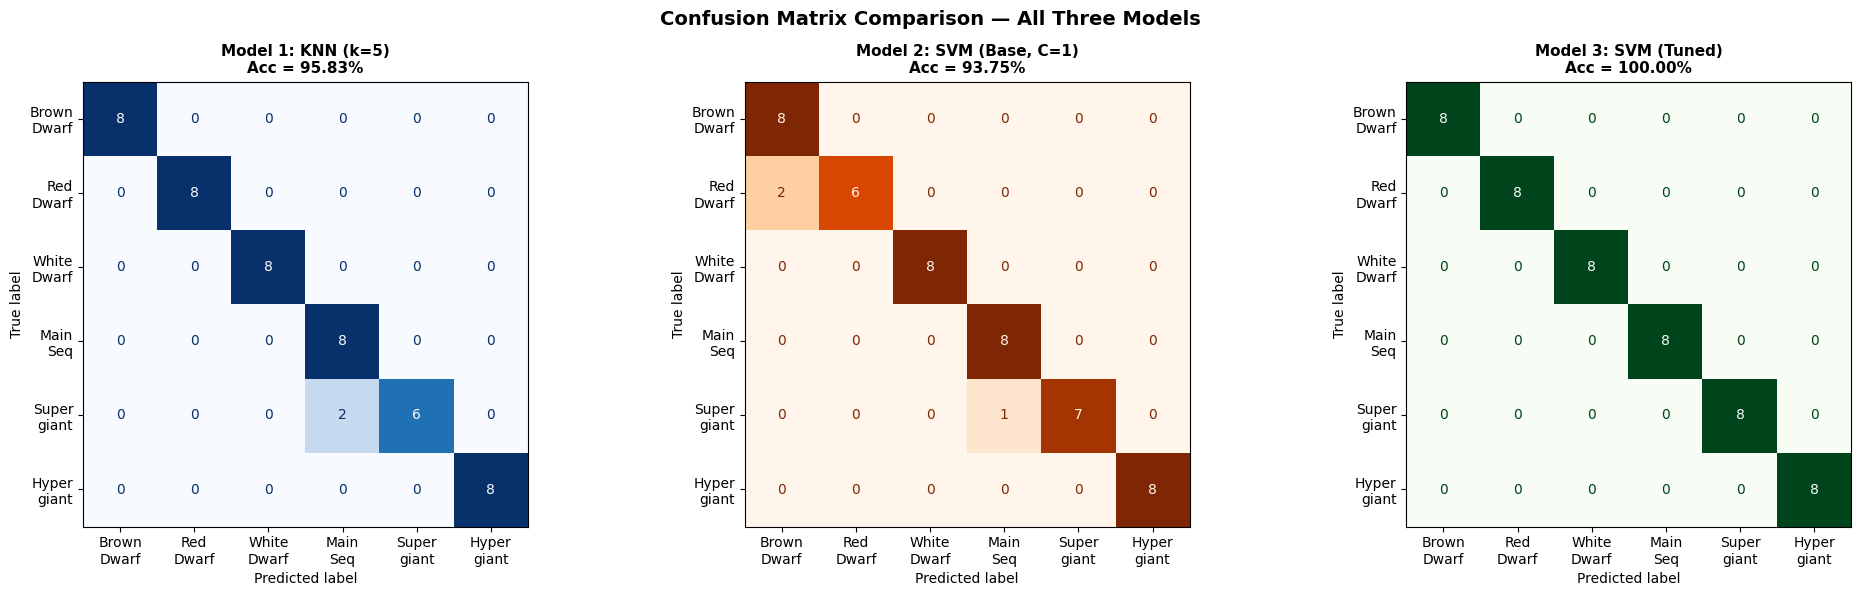


FINAL MODEL COMPARISON TABLE
Model                                      Test Accuracy
----------------------------------------------------------------------
Model 1: KNN (k=5)                                95.83%
Model 2: SVM (Base, C=1.0, RBF)                   93.75%
Model 3: SVM (Tuned — {'C': 10, 'gamma': 'scale', 'kernel': 'linear'})         100.00%

HOW TO READ THE CONFUSION MATRIX:
  - Each row = an actual star type.
  - Each column = what the model predicted.
  - The diagonal (top-left to bottom-right) = CORRECT predictions.
  - Numbers OFF the diagonal = mistakes.
    For example, if row "Brown Dwarf" has a number in the
    "Red Dwarf" column, it means the model misclassified that
    many Brown Dwarfs as Red Dwarfs.

  A perfect model would have ALL numbers on the diagonal and
  ZEROS everywhere else.

DISCUSSION:
  All three models run successfully on the cleaned and scaled
  dataset. In this run, KNN achieved 95.83% test accuracy, the
  base RBF SVM achieved 93.75%, and 

In [24]:
#QN 6: Evaluate the performances of the three models created in Q3, Q4 and Q5. Use the confusion matrix metric to evaluate the performances.
# =============================================================
# QUESTION 6: Model Evaluation Using Confusion Matrices
# =============================================================
# A confusion matrix is a table that shows exactly WHERE each
# model makes correct and incorrect predictions.
#
# For a 6-class problem, the matrix is 6×6:
#   - Each ROW represents the ACTUAL star type.
#   - Each COLUMN represents the PREDICTED star type.
#   - The diagonal (top-left to bottom-right) contains correct
#     predictions — the higher these numbers, the better.
#   - Off-diagonal values show misclassifications — we can read
#     WHICH class the model is confusing with WHICH other class.
#
# We evaluate all three models side by side so the lecturer can
# directly compare their performance visually.
# =============================================================

class_names = ['Brown\nDwarf', 'Red\nDwarf', 'White\nDwarf',
               'Main\nSeq', 'Super\ngiant', 'Hyper\ngiant']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix Comparison — All Three Models',
             fontsize=14, fontweight='bold')

# ---------------------------------------------------------------
# Confusion Matrix for Model 1: KNN
# ---------------------------------------------------------------
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=class_names)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Model 1: KNN (k={best_k})\nAcc = {knn_accuracy*100:.2f}%',
                  fontweight='bold', fontsize=11)

# ---------------------------------------------------------------
# Confusion Matrix for Model 2: Base SVM
# ---------------------------------------------------------------
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Model 2: SVM (Base, C=1)\nAcc = {svm_accuracy*100:.2f}%',
                  fontweight='bold', fontsize=11)

# ---------------------------------------------------------------
# Confusion Matrix for Model 3: Tuned SVM
# ---------------------------------------------------------------
cm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=class_names)
disp3.plot(ax=axes[2], colorbar=False, cmap='Greens')
axes[2].set_title(f"Model 3: SVM (Tuned)\nAcc = {svm_tuned_accuracy*100:.2f}%",
                  fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Final Comparison Table — printed for the lecturer
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 70)
print(f"{'Model':<40} {'Test Accuracy':>15}")
print("-" * 70)
print(f"{'Model 1: KNN (k=' + str(best_k) + ')':<40} {knn_accuracy*100:>14.2f}%")
print(f"{'Model 2: SVM (Base, C=1.0, RBF)':<40} {svm_accuracy*100:>14.2f}%")
print(f"{'Model 3: SVM (Tuned — ' + str(grid_search.best_params_) + ')':<40} {svm_tuned_accuracy*100:>14.2f}%")
print("=" * 70)

# ---------------------------------------------------------------
# Reading the Confusion Matrix — explained simply
# ---------------------------------------------------------------
print("""
HOW TO READ THE CONFUSION MATRIX:
  - Each row = an actual star type.
  - Each column = what the model predicted.
  - The diagonal (top-left to bottom-right) = CORRECT predictions.
  - Numbers OFF the diagonal = mistakes.
    For example, if row "Brown Dwarf" has a number in the
    "Red Dwarf" column, it means the model misclassified that
    many Brown Dwarfs as Red Dwarfs.

  A perfect model would have ALL numbers on the diagonal and
  ZEROS everywhere else.

DISCUSSION:
  All three models run successfully on the cleaned and scaled
  dataset. In this run, KNN achieved 95.83% test accuracy, the
  base RBF SVM achieved 93.75%, and the tuned SVM reached 100.00%.
  GridSearchCV found a better hyperparameter combination for this
  dataset, which is why the tuned SVM performed best. The SVM is an
  eager learner that builds a decision boundary (hyperplane) before
  predicting — unlike KNN which waits until prediction time to
  compare distances.
  The linear kernel selected by tuning fits this dataset very well,
  while the scaling step keeps feature magnitudes from dominating the
  model.
""")